In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"D:\car data.csv")

In [6]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Data Cleaning

In [11]:
print("Missing value per Columns")
df.isnull().sum()

Missing value per Columns


Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [9]:
df.shape

(301, 9)

In [10]:
df.duplicated().sum()

np.int64(2)

Drop Duplicates

In [12]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - df.shape[0]} duplicate rows")

Dropped 2 duplicate rows


In [13]:
txt_cols = ["Car_Name","Fuel_Type","Selling_type","Transmission"]
for c in txt_cols:
    df[c] = df[c].astype(str).str.strip()

# check categorical values

In [15]:
for c in ["Fuel_Type","Selling_type","Transmission","Owner"]:
    print(c,"-->",df[c].unique())

Fuel_Type --> ['Petrol' 'Diesel' 'CNG']
Selling_type --> ['Dealer' 'Individual']
Transmission --> ['Manual' 'Automatic']
Owner --> [0 1 3]


2. Data Validation

In [16]:
import datetime

current_year = datetime.datetime.now().year

validation_report = {
    "future_year_row":( df["Year"] > current_year ).sum(),
    "non_positive_selling_price":(df["Selling_Price"]<=0).sum(),
    "non_positive_present_price":(df['Present_Price']<=0).sum(),
    "non_positive_kms":(df['Driven_kms']<=0).sum(),
    "selling_price_gt_present_price":(df['Selling_Price'] > df['Present_Price']).sum()

}
validation_report

{'future_year_row': np.int64(0),
 'non_positive_selling_price': np.int64(0),
 'non_positive_present_price': np.int64(0),
 'non_positive_kms': np.int64(0),
 'selling_price_gt_present_price': np.int64(0)}

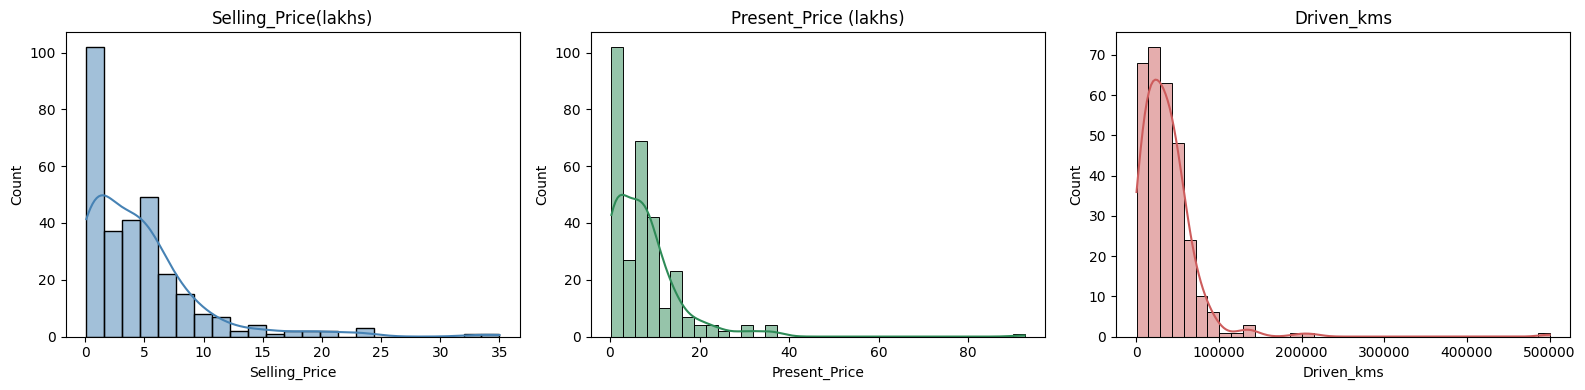

In [18]:
fig,axes = plt.subplots(1,3,figsize=(16,4))
sns.histplot(df["Selling_Price"],kde=True,ax=axes[0],color="steelblue")
axes[0].set_title("Selling_Price(lakhs)")

sns.histplot(df["Present_Price"],kde=True,ax=axes[1],color="seagreen")
axes[1].set_title("Present_Price (lakhs)")

sns.histplot(df["Driven_kms"],kde=True,ax=axes[2],color="indianred")
axes[2].set_title("Driven_kms")

plt.tight_layout()
plt.show()

3. Feature Extraction — KPIs (Key Performance Indicators)
Raw columns aren't always the most predictive. We engineer KPIs that better capture value depreciation and usage intensity:

    .Car_Age — how many years old the car is (from Year).
    .Depreciation_Ratio — Selling_Price / Present_Price, i.e. what fraction of showroom value the car retains. This is a strong proxy for overall condition/brand goodwill.
    .Kms_Per_Year — Driven_kms / Car_Age, a usage-intensity KPI (a 10-year-old car with 20,000 km is very different from a 2-year-old car with 20,000 km).
    .Price_Drop — absolute currency drop (Present_Price - Selling_Price).
    .One-hot encoding of categorical features (Fuel_Type, Selling_type, Transmission) and Car_Name grouped into Brand (first word of the name) to capture brand goodwill without an explosion of categories.

In [19]:
df["Car_Age"] = current_year - df["Year"]

df["Kms_Per_Years"] = df["Driven_kms"] / df["Car_Age"].replace(0, 1)

df["Depreciation_Ratio"] = df["Selling_Price"] / df["Present_Price"]
df["Price_Drop"] = df["Present_Price"] - df["Selling_Price"]

df["Brand"] = df["Car_Name"].str.split().str[0].str.lower()

brand_counts = df["Brand"].value_counts()
common_brands = brand_counts[brand_counts >= 3].index

df["Brand"] = df["Brand"].where(df["Brand"].isin(common_brands),"other")

df[["Car_Age","Kms_Per_Years","Depreciation_Ratio","Price_Drop","Brand"]].head()


,Car_Age,Kms_Per_Years,Depreciation_Ratio,Price_Drop,Brand
0,12,2250.000000,0.599284,2.24,ritz
1,13,3307.692308,0.497904,4.79,sx4
2,9,766.666667,0.736041,2.60,ciaz
3,15,346.666667,0.686747,1.30,wagon
4,12,3537.500000,0.669578,2.27,swift


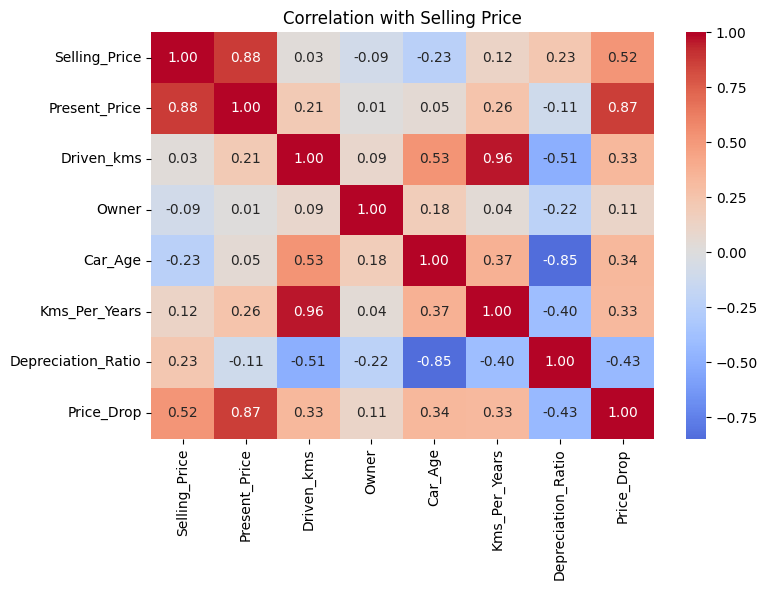

In [20]:
num_columns = ["Selling_Price","Present_Price","Driven_kms","Owner","Car_Age",
               "Kms_Per_Years","Depreciation_Ratio","Price_Drop"]

plt.figure(figsize=(8,6))

sns.heatmap(df[num_columns].corr(),annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation with Selling Price")
plt.tight_layout()
plt.show()

In [21]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age',
       'Kms_Per_Years', 'Depreciation_Ratio', 'Price_Drop', 'Brand'],
      dtype='object')

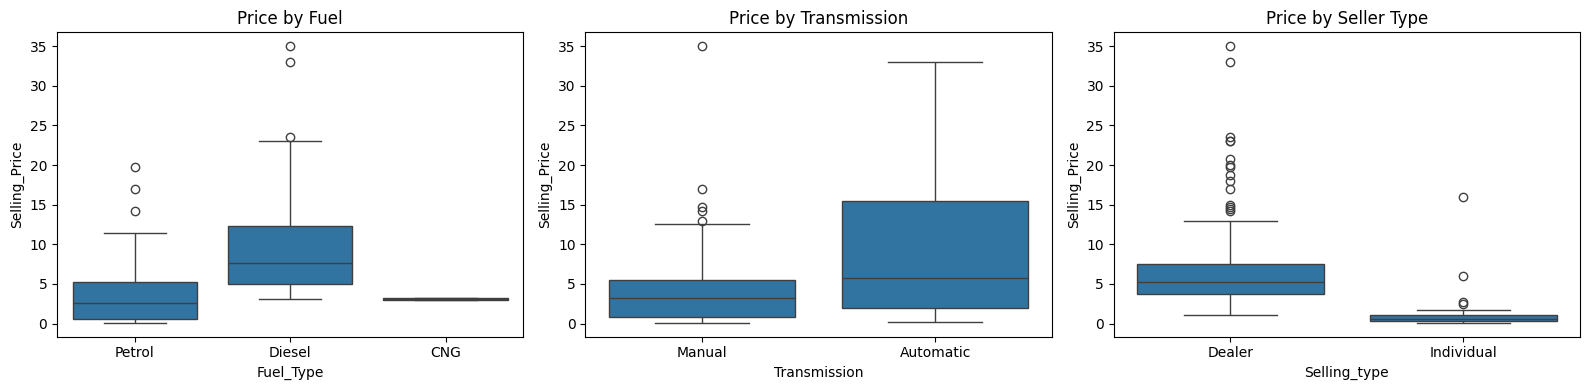

In [22]:
fig ,axes = plt.subplots(1,3,figsize=(16,4))
sns.boxplot(data=df,x="Fuel_Type",y="Selling_Price",ax=axes[0])
sns.boxplot(data=df,x="Transmission",y="Selling_Price",ax=axes[1])
sns.boxplot(data=df,x="Selling_type",y="Selling_Price",ax=axes[2])
axes[0].set_title("Price by Fuel")
axes[1].set_title("Price by Transmission")
axes[2].set_title("Price by Seller Type")
plt.tight_layout()
plt.show()

In [23]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_Per_Years,Depreciation_Ratio,Price_Drop,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,2250.000000,0.599284,2.24,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,3307.692308,0.497904,4.79,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,766.666667,0.736041,2.60,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,346.666667,0.686747,1.30,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,3537.500000,0.669578,2.27,swift


In [24]:
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.preprocessing import OneHotEncoder,StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression,ridge_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
target = "Selling_Price"

numeric_cols = ["Present_Price","Driven_kms","Owner","Car_Age","Kms_Per_Years","Depreciation_Ratio"]

categorical_cols = ["Fuel_Type","Selling_type","Transmission","Brand"]

x =df[ numeric_cols + categorical_cols]
y = df[target]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((239, 10), (60, 10))

In [26]:
preprocessor = ColumnTransformer(transformers=[
    ("num",StandardScaler(),numeric_cols),
    ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_cols)
])

models = {
    "Linear Regression":LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300,random_state=42)
}

In [31]:
results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor",preprocessor),("models",model)])
    pipe.fit(x_train,y_train)
    preds = pipe.predict(x_test)

    mae = mean_absolute_error(y_test,preds)
    rmse = mean_squared_error(y_test,preds) ** 0.5
    r2  = r2_score(y_test,preds)

    cv = KFold(n_splits=5,shuffle=True,random_state=42)
    cv_score = cross_val_score(pipe,x,y,cv=cv,scoring="r2")

    results[name] = {
        "Pipeline":pipe,
        "MAE":mae,
        "RMSE":rmse,
        "R2":r2,
        "CV_R2_mean":cv_score.mean(),
        "CV_R2_std":cv_score.std()
    }

    print(f"--- {name} ---")
    print(f"MAE:  {mae:.3f} lakhs")
    print(f"RMSE: {rmse:.3f} lakhs")
    print(f"R2: {r2:.3f}")
    print(f"cv R2 (5-fold): {cv_score.mean():.3f} +/- {cv_score.std():.3f}")
    print()


--- Linear Regression ---
MAE:  1.307 lakhs
RMSE: 2.498 lakhs
R2: 0.758
cv R2 (5-fold): 0.827 +/- 0.077

--- Random Forest ---
MAE:  1.391 lakhs
RMSE: 4.200 lakhs
R2: 0.315
cv R2 (5-fold): 0.821 +/- 0.244



In [32]:
# Print the fitted pipelines (shows preprocessing steps + model params)
for name , res in results.items():
    print(f"== {name} pipelines ==")
    print(res["Pipeline"])
    print()

# Build a comparison table: actual vs predicted from each model
comparison_df = pd.DataFrame({
    "Actual":y_test.values,
    "Predicated_LinearRegression": results["Linear Regression"]["Pipeline"].predict(x_test),
    "Predicated_RandomForest": results["Random Forest"]["Pipeline"].predict(x_test),
})

comparison_df["Error_LR"] = comparison_df["Actual"] - comparison_df["Predicated_LinearRegression"]
comparison_df["Error_RF"] = comparison_df["Actual"] - comparison_df["Predicated_RandomForest"]

comparison_df.round(2).head(15)

== Linear Regression pipelines ==
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Present_Price',
                                                   'Driven_kms', 'Owner',
                                                   'Car_Age', 'Kms_Per_Years',
                                                   'Depreciation_Ratio']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission',
                                                   'Brand'])])),
                ('models', LinearRegression())])

== Random Forest pipelines ==
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
               

,Actual,Predicated_LinearRegression,Predicated_RandomForest,Error_LR,Error_RF
0,8.99,8.13,8.97,0.86,0.02
1,8.35,8.54,8.23,-0.19,0.12
2,0.45,1.45,0.46,-1.00,-0.01
3,7.45,7.54,7.48,-0.09,-0.03
4,5.25,9.16,19.43,-3.91,-14.18
5,5.25,5.22,5.33,0.03,-0.08
6,5.85,7.53,6.59,-1.68,-0.74
7,1.15,1.31,1.15,-0.16,0.00
8,9.25,7.85,8.55,1.40,0.70
9,0.38,-0.90,0.33,1.28,0.05


In [33]:
# compare models 
results_df = pd.DataFrame({
    name: {k: v for k , v in res.items() if k != "Pipeline"}
    for name, res in results.items()
}).T
results_df

,MAE,RMSE,R2,CV_R2_mean,CV_R2_std
Linear Regression,1.306727,2.497948,0.757898,0.826567,0.077169
Random Forest,1.390907,4.200460,0.315420,0.820897,0.243997


Best models: Linear Regression


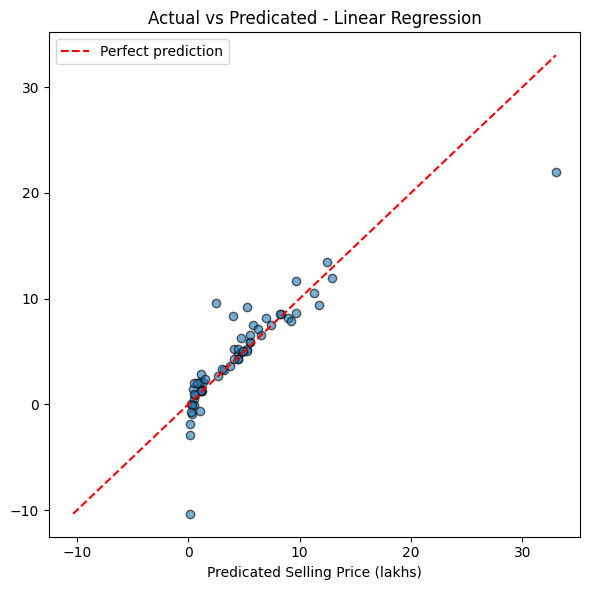

In [34]:
best_name = results_df["R2"].astype(float).idxmax()
best_pipeline = results[best_name]["Pipeline"]
print(f"Best models: {best_name}")

preds = best_pipeline.predict(x_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test,preds,alpha=0.6,edgecolor="k")
lims = [min(y_test.min(),preds.min()), max(y_test.max(),preds.max())]

plt.plot(lims,lims,"r--",label="Perfect prediction")
plt.xlabel("Actual Selling Price (lakhs)")
plt.xlabel("Predicated Selling Price (lakhs)")
plt.title(f"Actual vs Predicated - {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

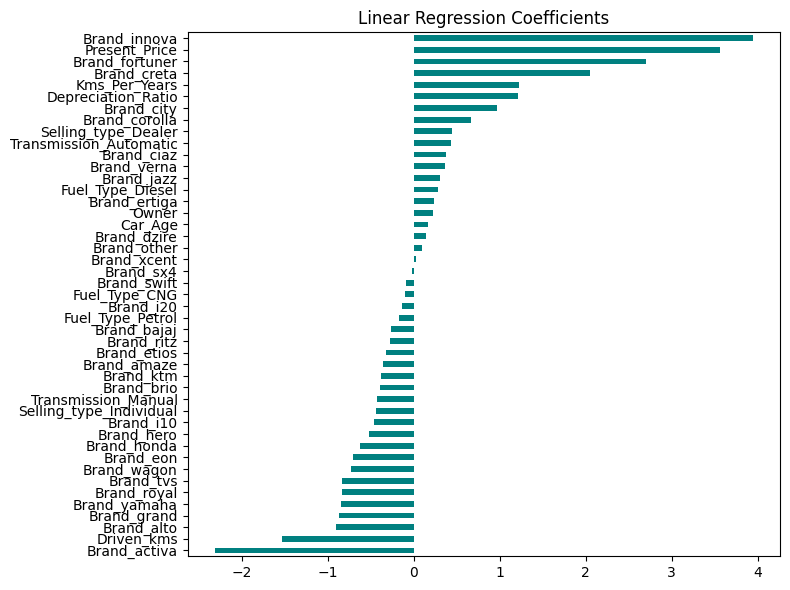

In [39]:
# Feature importance (only meaningful for tree-based models)
if best_name == "Random Forest":
    ohe_cols = best_pipeline.named_steps["preprocess"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
    all_feature_names = numeric_cols + list(ohe_cols)
    importances = best_pipeline.named_steps["model"].feature_importances_

    fi = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=fi.values, y=fi.index, color="teal")
    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    coefs = best_pipeline.named_steps["models"].coef_
    ohe_cols = best_pipeline.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
    all_feature_names = numeric_cols + list(ohe_cols)
    coef_series = pd.Series(coefs, index=all_feature_names).sort_values()
    plt.figure(figsize=(8, 6))
    coef_series.plot(kind="barh", color="teal")
    plt.title("Linear Regression Coefficients")
    plt.tight_layout()
    plt.show()